In [1]:
from keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_word=200)

In [2]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [3]:
print(len(train_input[0]))

218


In [4]:
print(len(train_input[1]))

189


In [5]:
print(train_input[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [6]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [7]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [8]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [9]:
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


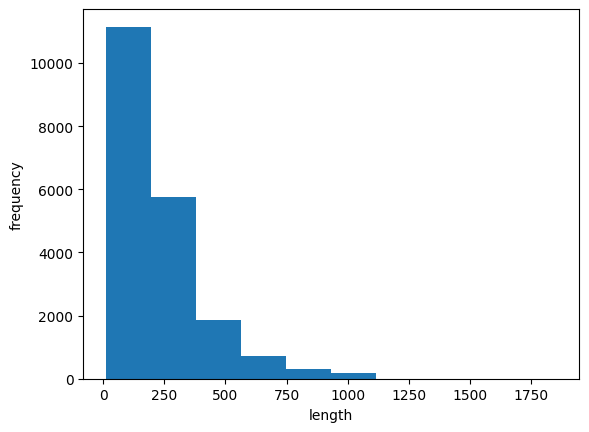

In [10]:
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [11]:
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)

In [12]:
print(train_seq.shape)

(20000, 100)


In [13]:
print(train_seq[0])

[   10     4    20     9   540   364   352     5    45     6 29217   589
    33   269     8  2715   142  1621     5   821    17    73    17   204
     5  2908    19    55  1763  4697    92    66   104    14    20    93
    76  1488   151    33     4    58    12   188   626   151    12   215
    69   224   142    73   237     6   964     7  1446  2289   188   626
   103    14    31    10    10   451     7  1465     5   599    80    91
  1329    30   685    34    14    20   151    50    26   131    49  7717
    84    46    50    37    80    79     6  1968    46     7    14    20
    10    10   470   158]


In [14]:
print(train_input[0][-10:])

[6, 1968, 46, 7, 14, 20, 10, 10, 470, 158]


In [15]:
print(train_seq[5])

[    0     0     0     0     1   542   195    19    49  3005  2656   190
     4  2409   352 32541   183    10    10    13    82    79     4  1384
    36    71   269     8  1465    25    19    49     7     4  2177  9752
 34466  3910   538    10    10    48    25    40  2158    11   843   538
    40 14062   543     5     4  3253   568    95    14   238    56   129
   890    10    10    21   691    94   364   352  2661  2208    11   190
    24   484  4170     7    94   205   405    10    10    87   816    34
    49 12916     7 25790  4175  1208 25790  4753   290  3303    46    48
    64    18     4   816]


In [16]:
val_seq = pad_sequences(val_input, maxlen=100)

In [17]:
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [18]:
train_oh = keras.utils.to_categorical(train_seq)

MemoryError: Unable to allocate 1.29 TiB for an array with shape (2000000, 88587) and data type float64